<a href="https://colab.research.google.com/github/NGuerrero23/TT-2C2025-Data-Analitycs-Notebooks/blob/main/Clase_4/Resolucion_Clase_04_Datos_nulos_y_duplicados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Datos Nulos y Duplicados
**Objetivo:**
* Familiarizarse con la identificación de valores nulos en un DataFrame.
* Reconocer y contar duplicados en un conjunto de datos.


# Datos Nulos




**Instrucciones:**

1. Descargar el siguiente conjunto de datos: [satis_clientes.csv](https://drive.google.com/file/d/169MG1sSG8IqTtLdJwIlnBOhMkF_CN_Tb/view?usp=drive_link).
2. Cargar los datos en un DataFrame en Python usando Pandas.
Utilizar el método `isnull()` para identificar las filas con datos faltantes y contar el número de valores nulos por columna.
3. Usar el método `duplicated()` para identificar las filas duplicadas y contar cuántas filas duplicadas hay en total.
4. Crear un informe que incluya:
  * La cantidad total de registros en el DataFrame.
  * La cantidad total de valores nulos por columna.
  * La cantidad de filas duplicadas.
  * Un subconjunto de los registros duplicados para que se vea el contenido.  



## Ver en documentación oficial

[Pandas Working with missing data](https://pandas.pydata.org/docs/user_guide/missing_data.html)
[NumPy Data Types](https://numpy.org/doc/2.3/user/basics.types.html)

**Sobre NULL**

* NULL es la representación en bases de datos SQL.
* Cuando importás datos a pandas (ej: con pd.read_sql o pd.read_csv), esos NULL se convierten en NaN o NaT dentro de pandas.
* En pandas casi siempre vas a ver NaN (nulos numéricos/objetos) o NaT (nulos de tiempo).
* No vas a ver NULL directamente, salvo en la base de datos antes de importar.

## Veamos algunos comandos antes de comenzar
De forma similar a numpy, pandas también tiene algunas funciones útiles para identificar y detectar valores nulos.

In [ ]:
import numpy as np
import pandas as pd

La función pd.isnulll() detecta valores nulos (como NaN, None, etc.) y devuelve True si el valor es nulo, o False si no lo es.

In [ ]:
pd.isnull(np.nan)

In [ ]:
pd.isnull(None)

True

La función pd.isna() en pandas se utiliza para detectar valores nulos (missing values) en objetos, como NaN, None, etc.

In [ ]:
pd.isna(np.nan)

True

In [ ]:
pd.isna(None)

También podemos usarlo con Series

In [ ]:
pd.isnull(pd.Series([1, np.nan, 7]))

,0
0,False
1,True
2,False


O incluso con Dataframes

In [ ]:
pd.isnull(pd.DataFrame({
    'Column A': [1, np.nan, 7],
    'Column B': [np.nan, 2, 3],
    'Column C': [np.nan, 2, np.nan]
}))

,Column A,Column B,Column C
0,False,True,True
1,True,False,False
2,False,False,True


## Veamos con un caso mas complejo

In [ ]:
# Al ejecutar este bloque, Google nos solicitará los permisos
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Para facilitar las tareas, podemos cambiar la ruta de trabajo con el método chdir() de la librería os de python.
import os
os.chdir('/content/drive/MyDrive/Colab_Notebooks/datasets')
# os.chdir('/content/drive/My Drive/{mi ruta de carpetas}')
!ls # muestra el contenido de la carpeta

booking_db_nulls.sqlite  hotels.csv	netflix_titles.csv  satis_clientes.csv
booking_db.sqlite	 hotels.gsheet	reviews.csv	    users.csv


In [ ]:
import pandas as pd

# Cargar datos
df = pd.read_csv('satis_clientes.csv')
df.head(8)

,id,Empresa,Fecha,Calificación,Comentarios
0,1,Mitchell Group,11/12/2024,1.0,Integer ac leo. Pellentesque ultrices mattis o...
1,2,Kuhn-Fay,25/01/2024,4.0,Vestibulum ac est lacinia nisi venenatis trist...
2,3,Moen-Blick,11/11/2024,3.0,Aliquam quis turpis eget elit sodales sceleris...
3,4,McDermott Inc,01/12/2024,1.0,NaN
4,5,Keebler Inc,12/01/2024,4.0,Integer ac leo. Pellentesque ultrices mattis o...
5,6,Dickinson Inc,30/04/2024,1.0,Phasellus in felis. Donec semper sapien a libe...
6,7,Moen-Hartmann,11/03/2024,NaN,NaN
7,8,Lubowitz and Sons,27/01/2024,NaN,"Donec diam neque, vestibulum eget, vulputate u..."


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            1128 non-null   int64  
 1   Empresa       1128 non-null   object 
 2   Fecha         1128 non-null   object 
 3   Calificación  904 non-null    float64
 4   Comentarios   818 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 44.2+ KB


Si bien lo vamos a ver más adelante, asi podemos cambiar el tipo de dato de una columna

In [ ]:
df["Empresa"] = df["Empresa"].astype("string")

In [ ]:
# Identificar valores nulos
valores_nulos = df.isnull().sum()
print(f'Valores nulos: \n{valores_nulos}')

In [ ]:
# Asi listamos los valores con alguna celda nula
df[df.isnull().any(axis=1)]

Incluso podemos representar gráficamente los valos nulos (NaN)

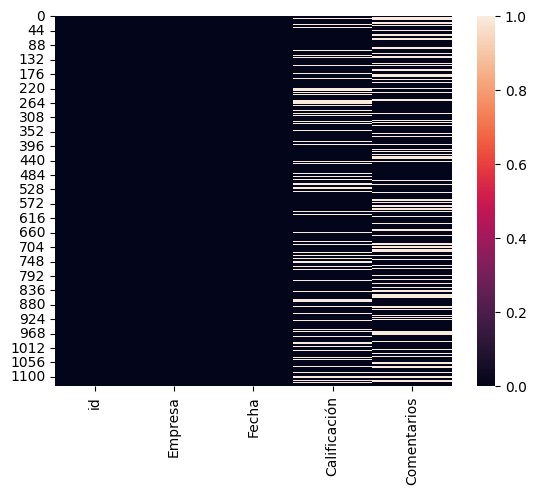

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull())
# sns.heatmap(~df.isnull())
plt.show()

Vamos a cargar datos de una DB que tiene Nulls

In [ ]:
# Importamos las librerías
import sqlite3

In [ ]:
#Establecemos la conexión a la db
conexion = sqlite3.connect('/content/drive/MyDrive/Colab_Notebooks/datasets/booking_db_nulls.sqlite')

In [ ]:
df = pd.read_sql('''
    SELECT
        *
    FROM reviews
    ;
''', conexion, index_col='review_id', parse_dates=['review_date'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            1128 non-null   int64  
 1   Empresa       1128 non-null   string 
 2   Fecha         1128 non-null   object 
 3   Calificación  904 non-null    float64
 4   Comentarios   818 non-null    object 
dtypes: float64(1), int64(1), object(2), string(1)
memory usage: 44.2+ KB


In [ ]:
df.isnull().sum()

In [ ]:
df[df.isnull().any(axis=1)]
# df[df.isnull().any(axis=1)].info()

# Datos duplicados

In [ ]:
# Cargar datos
df = pd.read_csv('satis_clientes.csv')
df.head(8)

,id,Empresa,Fecha,Calificación,Comentarios
0,1,Mitchell Group,11/12/2024,1.0,Integer ac leo. Pellentesque ultrices mattis o...
1,2,Kuhn-Fay,25/01/2024,4.0,Vestibulum ac est lacinia nisi venenatis trist...
2,3,Moen-Blick,11/11/2024,3.0,Aliquam quis turpis eget elit sodales sceleris...
3,4,McDermott Inc,01/12/2024,1.0,NaN
4,5,Keebler Inc,12/01/2024,4.0,Integer ac leo. Pellentesque ultrices mattis o...
5,6,Dickinson Inc,30/04/2024,1.0,Phasellus in felis. Donec semper sapien a libe...
6,7,Moen-Hartmann,11/03/2024,NaN,NaN
7,8,Lubowitz and Sons,27/01/2024,NaN,"Donec diam neque, vestibulum eget, vulputate u..."


In [ ]:
# Identificar duplicados
duplicados = df.duplicated()
cantidad_duplicados = duplicados.sum()
print(f'Duplicados:\n{duplicados}')
print(f'Cantidad de duplicados: {cantidad_duplicados}')

Duplicados:
0       False
1       False
2       False
3       False
4       False
        ...  
1123    False
1124    False
1125    False
1126    False
1127    False
Length: 1128, dtype: bool
Cantidad de duplicados: 128


In [ ]:
# Crear subconjunto de duplicados
registros_duplicados = df[duplicados]
# Mostrar en consola

print(f'\nCantidad total de registros: {len(df)}')
print(f'Cantidad de registros duplicados: {cantidad_duplicados}')
print(registros_duplicados.head())


Cantidad total de registros: 1128
Cantidad de registros duplicados: 128
    id                          Empresa       Fecha  Calificación  \
10  10                     Legros-Olson  12/11/2024           5.0   
12  11                     Harris-Davis  13/11/2024           1.0   
18  16  White, Balistreri and Daugherty  29/06/2024           5.0   
45  42                 Keebler and Sons  28/09/2024           5.0   
48  44                  Erdman-Parisian  07/03/2024           2.0   

                                          Comentarios  
10                                                NaN  
12  Nullam sit amet turpis elementum ligula vehicu...  
18                                                NaN  
45                                                NaN  
48  Curabitur in libero ut massa volutpat convalli...  


In [ ]:
registros_duplicados.dtypes

,0
id,int64
Empresa,string[python]
Fecha,object
Calificación,float64
Comentarios,object


In [ ]:
duplicado_10 = df["id"].duplicated()
print(duplicado_10)

0       False
1       False
2       False
3       False
4       False
        ...  
1123    False
1124    False
1125    False
1126    False
1127    False
Name: id, Length: 1128, dtype: bool


# Actividad 2: Exploración y limpieza preliminar con Python.
**Contexto**
En esta actividad, trabajarás guiado por Luis, nuestro Analista de BI, con una planilla de Google Sheets que registra la temperatura corporal de un grupo de personas durante 10 días. Debes realizar un examen preliminar para identificar datos problemáticos, como duplicados y valores nulos. Esta práctica te ayudará a dar los pasos previos a la limpieza de datos, un componente vital en cualquier proyecto de análisis.

**Objetivos**
* Identificar los datos duplicados y nulos en el conjunto.
* Analizar el mejor tratamiento para los datos anómalos y nulos.

**Ejercicio práctico**
1. Crear un dataframe a partir de la planilla de cálculo y efectuar un examen preliminar.
2. Identificar los datos:

  a. duplicados

  b. nulos
3. Analizá cuál sería el mejor tratamiento para los datos anómalos (fuera de rango) y nulos en los siguientes contextos **(YA RESUELTO)**:

<center><img src="https://drive.google.com/uc?id=1CaYiA8Sc5Z1KPEA6NZ2DYWuCzaihZ6BQ"></center>

**Sets de datos**
* [Actividad 2](https://docs.google.com/spreadsheets/d/1-rUn4TUwpGrLE1DH8moeiR5eSyeF-jOOTpfhRgZxVIQ/edit?usp=sharing)

**¿Por qué importa esto en SynthData?**

La exploración y limpieza de datos son pasos esenciales para garantizar que cualquier análisis posterior sea robusto y significativo. En SynthData, nos enfrentamos a datos en diferentes formatos, y es crucial asegurarnos de que estén listos para ser analizados. Esta actividad te enseñará a detectar problemas comunes en conjuntos de datos, como duplicados y valores nulos, y cómo abordarlos adecuadamente.



### 1) Crear el dataframe

In [ ]:
# importar la librería
# crear el dataframe
# probar que se haya cargado el dataframe
import pandas as pd
df = pd.read_csv('https://docs.google.com/spreadsheets/d/1-rUn4TUwpGrLE1DH8moeiR5eSyeF-jOOTpfhRgZxVIQ/gviz/tq?tqx=out:csv&sheet=')
df

,nombre,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10
0,Marcellus Antosik,36.85,36.01,37.36,37.85,36.31,36.55,36.71,37.79,36.44,36.86
1,Olia Thomson,36.06,36.42,36.16,36.03,36.00,36.08,37.45,37.92,37.53,36.54
2,Almeta Meredith,36.89,37.74,36.16,36.59,37.93,37.12,36.34,36.04,NaN,37.05
3,Massimiliano Waller,36.50,37.91,NaN,36.16,37.41,37.73,36.57,37.94,36.03,36.80
4,Melody Fedynski,37.90,37.69,36.55,37.06,37.81,36.77,36.89,36.35,37.36,37.08
...,...,...,...,...,...,...,...,...,...,...,...
3013,Marc Pullinger,36.07,37.73,36.29,37.37,36.31,36.73,36.65,36.48,37.62,37.13
3014,Marnia Carillo,NaN,36.93,36.47,38.00,37.94,36.93,NaN,36.01,37.02,37.51
3015,Vic Zanotti,37.19,36.49,37.24,37.10,36.27,37.42,36.92,36.54,37.13,37.02
3016,Hoyt Koenen,37.57,37.23,36.76,36.17,36.61,37.21,37.66,37.18,36.45,36.68


###1.2) Exploración preliminar
Los métodos de exploración son esenciales para obtener una comprensión inicial de los datos y su estructura.
Algunos de los métodos más utilizados son:
* `df.head(n)`: muestra las primeras n filas del dataframe (por defecto n = 5).
* `df.tail(n)`: muestra las últimas n filas del dataframe.
* `df.info()`: proporciona un resumen del dataframe.
* `df.describe()`: genera estadísticas que veremos más adelante.
* `df.shape`: devuelve una tupla que contiene el número de filas y columnas del dataframe.
* `df.columns`: devuelve una lista de los nombre de las columnas del dataframe.
* `df.index`: devuelve los índices del dataframe.
* `df.dtypes`: devuelve los tipos de datos de cada columna.
* `df.isnull()`: devuelve un dataframe booleano que indica si hay valores nulos en el dataframe. Tiene una función inversa: `df.notnull()`.
* `df.value_counts()`: cuenta las ocurrencias de los valores de una serie.
* `df.unique()`: devuelve los valores únicos de una columna.
* `df.sample(n)`: devuelve una muestra aleatoria de n filas

In [ ]:
# Muestra de los 4 primeros registros
df.head(4)

In [ ]:
# Muestra de los últimos 6 registros
df.tail(6)

In [ ]:
# Muestra los nombres de las columnas, cuántos valores hay en cada una, y qué tipo de dato contiene
df.info()

In [ ]:
# Muestra el resumen estadístico de las columnas. Conteo, promedio, mínimo y máximo...
df.describe()

In [ ]:
# Cantidad de registros y columnas
df.shape

(3018, 11)

In [ ]:
# Nombres de las columnas
df.columns

Index(['nombre', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6', 'd7', 'd8', 'd9', 'd10'], dtype='object')

In [ ]:
# Rango de los índices
df.index

RangeIndex(start=0, stop=3018, step=1)

In [ ]:
# Tipo de dato que hay en cada columna
df.dtypes

In [ ]:
# Un dataframe que muestra True donde falta el dato
df.isnull()

In [78]:
# Muestra cuántas veces se repiten los valores en cada columna
df['d4'].value_counts()

#df1=df.value_counts()>=2
#df1.sum()

np.int64(10)

In [69]:
# Muestra los valores de una columna, sin repetidos
df['d1'].unique()

array([36.85, 36.06, 36.89, 36.5 , 37.9 , 36.47, 36.27, 37.59, 36.72,
       36.32, 36.79, 36.02, 37.23, 36.24, 36.73, 36.93, 37.76, 36.16,
       37.81, 37.31, 36.25, 36.23, 36.04, 36.97, 37.52, 36.77,   nan,
       37.48, 36.36, 36.12, 37.2 , 36.81, 37.43, 37.02, 36.52, 37.98,
       37.46, 36.55, 37.45, 36.07, 37.05, 36.91, 36.41, 36.05, 36.96,
       36.  , 36.11, 37.75, 37.87, 37.88, 37.63, 37.15, 36.49, 36.3 ,
       37.97, 38.  , 37.64, 37.41, 36.53, 36.68, 37.58, 37.55, 37.77,
       37.83, 36.33, 36.82, 36.98, 37.69, 36.29, 36.67, 37.65, 37.16,
       36.95, 37.71, 37.68, 37.86, 36.87, 36.48, 37.91, 36.61, 37.32,
       37.5 , 36.39, 37.18, 36.4 , 37.82, 36.03, 37.33, 37.84, 37.17,
       36.21, 37.51, 37.57, 37.78, 36.08, 37.99, 37.09, 36.84, 37.53,
       36.56, 37.44, 36.09, 37.34, 36.15, 36.64, 36.17, 36.63, 37.73,
       36.92, 36.1 , 37.1 , 37.24, 36.51, 36.76, 36.86, 36.75, 36.65,
       37.7 , 37.29, 36.8 , 37.42, 36.38, 37.94, 36.46, 37.39, 36.71,
       37.11, 37.25,

In [ ]:
# Muestra aleatoria de 10 registros
df.sample(10)

❓ ¿Podrías decir si hay valores nulos en este dataframe?

✨ En un primer análisis, ya podemos decir que hay valores nulos:
tanto `shape` como `index` indican que hay 3018 registros, pero `info()` nos da la pauta de que la única columna que no tiene valores nulos es la de nombres.

###2) Ubicar datos duplicados y nulos

#### Duplicados
Para trabajar con datos duplicados, el método principal es `duplicated()` que devuelve un valor booleano por cada fila, indicando si es duplicado o no. Devuelve `True`, si una fila es duplicado de alguna anterior.
* Con el parámetro `subset`, permite buscar duplicados en columnas específicas.
* Combinada con otras funciones, podemos obtener más resultados, por ejemplo, `df.duplicated().sum()` cuenta  la cantidad de filas duplicadas


In [ ]:
# Saber cuáles filas son duplicado
df.duplicated()
# df.duplicated().sum()

In [ ]:
# Saber si las columnas d4, d5 y d6 tienen valos duplicados
df.duplicated(subset=["d4","d5","d6"])
#df.duplicated(subset=["d4","d5","d6"]).sum()

# es más eficiente q hacer:
# df[['d4','d5','d6']].duplicated()

#### Nulos
El método isnull() nos ofrece un dataframe con valores booleanos. Esta función puede combinarse con otras, para obtener diferentes resultados:

* Gracias al tipado dinámico de python, los valores booleanos se traducen automáticamente a 1 y 0, en caso de que alguna función lo requiera. Entonces, podemos utilizar la función sum() para obtener la cantidad de valores nulos en cada columna.
* any() se puede utilizar para verificar si hay valores nulos en filas (axis = 1) o columnas.

In [ ]:
# Cantidad de valores nulos
df.isnull().sum()

In [ ]:
# Nulos
df.isnull().any() # en columnas
#df.isnull().any(axis = 1) # en filas (podremos saber qué registros tienen completos sus datos)

,0
nombre,False
d1,True
d2,True
d3,True
d4,True
d5,True
d6,True
d7,True
d8,True
d9,True


💡 Podemos filtrar el dataframe para mostrar sólo las filas que contienen valores nulos en una columna específica.
La sintaxis es la siguiente: `df[df["columna"].isnull()]`

In [79]:
# Obtenemos los registros que tengan valores nulos en el día 7
df[df["d7"].isnull()]

,nombre,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10
22,Kellsie Donahue,36.23,37.71,36.50,NaN,37.67,37.83,NaN,36.02,37.84,36.84
49,Sonya Seignior,37.76,36.67,37.83,36.54,37.79,37.35,NaN,37.34,37.44,37.55
69,Cherey Frenzel,NaN,37.90,36.00,37.02,36.13,37.94,NaN,NaN,37.13,37.78
159,Nerita Moorhead,36.15,37.97,37.97,37.69,36.02,36.25,NaN,36.86,36.71,36.30
179,Harmony Becerro,36.91,36.04,37.18,37.19,36.96,NaN,NaN,37.03,36.56,37.98
...,...,...,...,...,...,...,...,...,...,...,...
2955,Evangeline Vaux,36.44,37.76,36.55,NaN,36.06,37.74,NaN,37.92,37.65,36.28
2957,Terrie Pettingall,37.86,37.36,36.37,37.94,36.73,37.20,NaN,37.26,37.34,36.71
2965,Jarrett Meagher,37.07,36.64,36.95,36.51,36.62,36.06,NaN,37.14,36.04,36.48
2986,Reginauld Verdie,37.52,37.84,37.67,36.56,36.19,37.22,NaN,37.98,36.41,36.00


---
<center>
<img src="https://drive.google.com/uc?id=1Siw64v_zlLaIAqtT7uxj8l9POO9C9b7j">
</center>